<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/iLogos/nsst.jpg" width="400" height="100">

# DEMI | NOVA SST

## Mecânica dos Sólidos I

# II. Análise de extensões. Extensometria. Equações da compatibilidade.

## Problema 12 <a name="PII512"></a>

Considere as seguintes componentes do campo de deslocamentos, $\underline{u} \equiv \vec{u}$, em relação a um sistema de coordenadas $S$:

\begin{equation*}
	u_x \equiv u = kxy \quad u_y \equiv v = kxy \quad u_z \equiv w = 2k(x+y)z \quad\textrm{(mm)}
\end{equation*}

Assuma $k$ um valor constante de pequena amplitude para que possa ser válida a teoria das deformações infinitesimais.

[a)](#A) Determine a matriz do tensor das deformações infinitésimal no referencial $S$.

[b)](#B) Calcule a deformação linear na direção com cossenos diretores: $l=m=n=1/\sqrt{3}$. Avalie o resultado para o
ponto $P(1,2,3)$.

## Resolução

#### a) Determine a matriz do tensor das deformações infinitésimal no referencial $S$.<a name="A"></a>

([enunciatum](#PII512))

A matriz do tensor das deformações infinitésimal pode ser diretamente obtido a partir das derivadas particiais do campo
de deslocamentos enunciado,

\begin{equation*}
\begin{aligned}
\underline{\underline{\varepsilon}} \equiv [\varepsilon] \equiv \varepsilon_{ij}
&=
\begin{bmatrix}
\varepsilon_{xx} & \varepsilon_{xy} & \varepsilon_{xz}\\
\varepsilon_{yx} & \varepsilon_{yy} & \varepsilon_{yz} \\
\varepsilon_{zx} & \varepsilon_{zy} & \varepsilon_{zz} \\
\end{bmatrix} =
\begin{bmatrix}
\varepsilon_{xx} & \gamma_{xy}/2 & \gamma_{xz}/2 \\
\gamma_{yx}/2 & \varepsilon_{yy} & \gamma_{yz}/2 \\
\gamma_{zx}/2 & \gamma_{yz}/2 & \varepsilon_{zz} \\
\end{bmatrix} \\
&=
\begin{bmatrix}
\displaystyle\frac{\partial u}{\partial x}
& \displaystyle\frac{1}{2}\left(\frac{\partial u}{\partial y} + \frac{\partial v}{\partial x} \right)
& \displaystyle\frac{1}{2}\left(\frac{\partial u}{\partial z} + \frac{\partial w}{\partial x} \right) \\
\displaystyle\frac{1}{2}\left(\frac{\partial v}{\partial x} + \frac{\partial u}{\partial y} \right)
& \displaystyle\frac{\partial v}{\partial y}
& \displaystyle\frac{1}{2}\left(\frac{\partial v}{\partial z} + \frac{\partial w}{\partial y} \right) \\
\displaystyle\frac{1}{2}\left(\frac{\partial w}{\partial x} + \frac{\partial u}{\partial z} \right)
& \displaystyle\frac{1}{2}\left(\frac{\partial v}{\partial z} + \frac{\partial w}{\partial y} \right)
& \displaystyle\frac{\partial w}{\partial z} \\
\end{bmatrix} \\
\end{aligned}
\end{equation*}

In [30]:
import numpy as np
import sympy as sy
from sympy import diff
from sympy import symbols
import matplotlib.pyplot as plt

u, v, w, x, y, z, k = symbols('u v w x y z k')

def u(x,y,k): return k*x*y
def v(x,y,k): return k*x*y
def w(x,y,z,k): return 2*k*(x + y)*z

u1 = u(x,y,k)
v1 = v(x,y,k)
w1 = w(x,y,z,k)

print('matriz das deformações [D]:\n')

exx = diff(u1, x)
print('exx = du/dx :',exx)
eyy = diff(v1, y)
print('eyy = dv/dy :',eyy)
ezz = diff(w1, z)
print('ezz = dw/dz :',ezz)
exy  = 0.5*(diff(u1, y) + diff(v1, x) )
print('exy = 1/2 gxy = 1/2 (du/dy + dv/dx )  :',exy)
exz  = 0.5*(diff(u1, z) + diff(w1, x) )
print('exz = 1/2 gxz = 1/2 (du/dz + dw/dx )  :',exz)
eyz  = 0.5*(diff(v1, z) + diff(w1, y) )
print('eyz = 1/2 gxy = 1/2 (dv/dz + dw/dy )  :',eyz)

def mD(exx,exy,exz,eyy,eyz,ezz):
    return np.array([[exx,exy,exz],[exy,eyy,eyz],[exz,eyz,ezz]])

mD0 = mD(exx,exy,exz,eyy,eyz,ezz)
print('\n[mD0] = \n',mD0)

matriz das deformações [D]:

exx = du/dx : k*y
eyy = dv/dy : k*x
ezz = dw/dz : 2*k*(x + y)
exy = 1/2 gxy = 1/2 (du/dy + dv/dx )  : 0.5*k*x + 0.5*k*y
exz = 1/2 gxz = 1/2 (du/dz + dw/dx )  : 1.0*k*z
eyz = 1/2 gxy = 1/2 (dv/dz + dw/dy )  : 1.0*k*z

[mD0] = 
 [[k*y 0.5*k*x + 0.5*k*y 1.0*k*z]
 [0.5*k*x + 0.5*k*y k*x 1.0*k*z]
 [1.0*k*z 1.0*k*z 2*k*(x + y)]]


Resultando,

\begin{equation*}
\begin{aligned}
\varepsilon_{ij}
&=k
\begin{bmatrix}
y & (x+y)/2 & z \\
(x+y)/2 & x & z \\
x & z & 2(x+y) \\
\end{bmatrix}
\end{aligned}
\end{equation*}

#### b) Calcule a deformação linear no ponto $P$ e numa direção com cossenos diretores: $l=m=n=1\sqrt{3}$.<a name="B"></a>

([enunciatum](#PII512))

A deformação linear infinitesimal numa determinada direção definida pelo versor $\vec{n}$ é dada por:

\begin{equation*}
\begin{aligned}
\varepsilon(\vec{n}) &=
{n}^T[D]\{n\} \\
& = k
\begin{bmatrix}
1/\sqrt{3} & 1/\sqrt{3} & 1/\sqrt{3}
\end{bmatrix}
\begin{bmatrix}
y & (x+y)/2 & z \\
(x+y)/2 & x & z \\
x & z & 2(x+y) \\
\end{bmatrix}
\begin{bmatrix}
1/\sqrt{3} \\ 1/\sqrt{3} \\ 1/\sqrt{3}
\end{bmatrix}
\end{aligned}
\end{equation*}

Versor n1:
 [ 0.577  0.577  0.577]


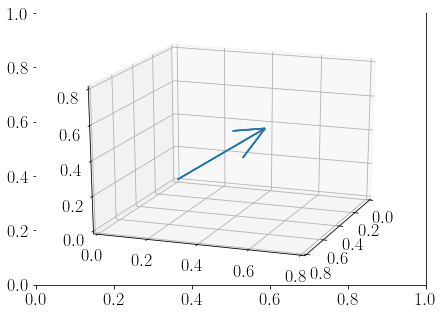

In [33]:
def versor(l,m,n): return np.array([l,m,n])

# versor 1: PQ
l1 = 1/np.sqrt(3)
m1 = 1/np.sqrt(3)
n1 = 1/np.sqrt(3)

np.set_printoptions(formatter={'float': '{: 0.3f}'.format})
n1 = versor(l1,m1,n1)
print('Versor n1:\n',n1)

vet = np.array([[0, 0, 0, l1, m1, n1]])
X, Y, Z, U, V, W = zip(*vet)
plt.rc('text', usetex=True)
plt.rc('font', family='serif', size=18)
fig, ax = plt.subplots(figsize=(7,5))
ax = fig.add_subplot(111, projection='3d')
ax.quiver(X, Y, Z, U, V, W)
ax.set_xlim([0, .8])
ax.set_ylim([0, .8])
ax.set_zlim([0, .8])
ax.view_init(20, 20)
plt.show()

In [32]:
epsPQ1 = np.dot(np.transpose(n1),np.dot(mD0,n1))
np.set_printoptions(formatter={'float': '{: 0.3f}'.format})
print('epsPQ = ',sy.simplify(sy.expand(epsPQ1)))

# ponto
Px = 1
Py = 2
Pz = 3

epsPQ1p = epsPQ1.subs({x:Px,y:Py,z:Pz,k:1e-3})
print('epsPQ1p =',epsPQ1p)

epsPQ =  1.33333333333333*k*(x + y + z)
epsPQ1p = 0.00800000000000000


Deformação linear na direção $\vec{n}$:

\begin{equation*}
\varepsilon(\vec{n}) = \frac{4}{3}k[x+y+z]
\end{equation*}

Deformação linear no ponto $P(1,2,3)$ na direção $\vec{n}$:

\begin{equation*}
\varepsilon(P,\vec{n}) = 0.008
\end{equation*}

---

Copyright (c) [Mecânica dos Sólidos I - DEMI - NOVA-SST]

Interactive computing by <a href="https://jupyter.org/" target="_blank"> <span
style="color:#333399"> Jupyter Notebook </span> </a> &nbsp;|&nbsp;Coded by <a href = "mailto: jmc.xavier@fct.unl.pt">José Xavier</a>

Licensed under  <a href="http://creativecommons.org/licenses/by-sa/4.0/"
target="_blank"> <span style="color:#333399;font-size: 20px"> CC BY-SA 4.0  </span></a>